In [1]:
#PART 1
import numpy as np
import pandas as pd

#1.1 Data loading 
titanic_df=pd.read_csv('Titanic-Dataset.csv')
iris_df=pd.read_csv('Iris.csv')


In [2]:
#1.2print the first 10 rows
datasets = {
    "Titanic Dataset": titanic_df,
    "Iris Dataset": iris_df
}

for name,df in datasets.items():
    print(f"======{name}=======")
    print(df.head(10))

======Titanic Dataset=======
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCart

In [3]:
#1.3examine
# (a)number of rows and columns
for name, df in datasets.items():
    print(f"=== {name} Analysis ===")
    print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")


=== Titanic Dataset Analysis ===
Dimensions: 891 rows, 12 columns
=== Iris Dataset Analysis ===
Dimensions: 150 rows, 6 columns


In [4]:
#(b)datatypes

for name,df in datasets.items():
    print(f"======{name}=======")
    print(df.dtypes)
    
    

======Titanic Dataset=======
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
======Iris Dataset=======
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object


In [5]:
#(c)missing values

for name,df in datasets.items():
    print(f"======{name}=======")
    print(df.isna().sum())


======Titanic Dataset=======
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
======Iris Dataset=======
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [6]:
#(d)duplicated values

for name,df in datasets.items():
    print(f"======{name}=======")
    print(df.duplicated().sum())



======Titanic Dataset=======
0
======Iris Dataset=======
0


In [7]:
#1.4 summary statistics

for name,df in datasets.items():
    print(f"======{name}=======")
    print(f"=====Numerical columns===")
    print(df.describe())

    #check if there are text/objects columns to describe
    cat_cols=df.select_dtypes(include=['object','str'])
    if not cat_cols.empty:
             print("\n-- categorical columns---")
             print(df.describe(include=['object','str']))
    print("\n--- info --")                          
    df.info()

======Titanic Dataset=======
=====Numerical columns===
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

-- categorical columns---

In [8]:
for name, df in datasets.items():
    print(f"=== {name} ===")
    print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
    

=== Titanic Dataset ===
Dimensions: 891 rows, 12 columns
=== Iris Dataset ===
Dimensions: 150 rows, 6 columns


In [9]:
#PART 2:DATA PREPROCESSING
#A.MISSING VALUES TREATMENT
#imputing Age with median since it is more robust with skewed datasets
titanic_df=pd.read_csv('Titanic-Dataset.csv')

#dataset before imputation
print(f"Missing Age{titanic_df['Age'].isna().sum()}")


age_median=titanic_df['Age'].median()
titanic_df['Age'] = titanic_df['Age'].fillna(age_median)

#imputing embarked with mode since it is categorical
embarked_mode=titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(embarked_mode)

#dropping the cabinn Column entirely due to many missing values
titanic_df = titanic_df.drop(columns=['Cabin'])

#Iris dataset did not have any missing values
datasets["Titanic Dataset"]= titanic_df

print("==== Titanic after imputation process ====")
print(titanic_df.isna().sum())

Missing Age177
==== Titanic after imputation process ====
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [10]:
#B.Duplicate Removal
print("=== Duplicate Removal Audit ===")

# 1. Titanic Dataset
titanic_dups = titanic_df.duplicated().sum()
titanic_df = titanic_df.drop_duplicates()
print(f"Titanic Dataset: Found and removed {titanic_dups} duplicate records.")

# 2. Iris Dataset
iris_dups = iris_df.duplicated().sum()
iris_df = iris_df.drop_duplicates()
print(f"Iris Dataset: Found and removed {iris_dups} duplicate records.")

# Update your tracking variables if you are using them later
datasets["Titanic Dataset"] = titanic_df
datasets["Iris Dataset"] = iris_df

=== Duplicate Removal Audit ===
Titanic Dataset: Found and removed 0 duplicate records.
Iris Dataset: Found and removed 0 duplicate records.


C. Outlier Detection & Treatment

First, visualize numerical columns with boxplots to identify potential outliers before deciding on treatment.


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


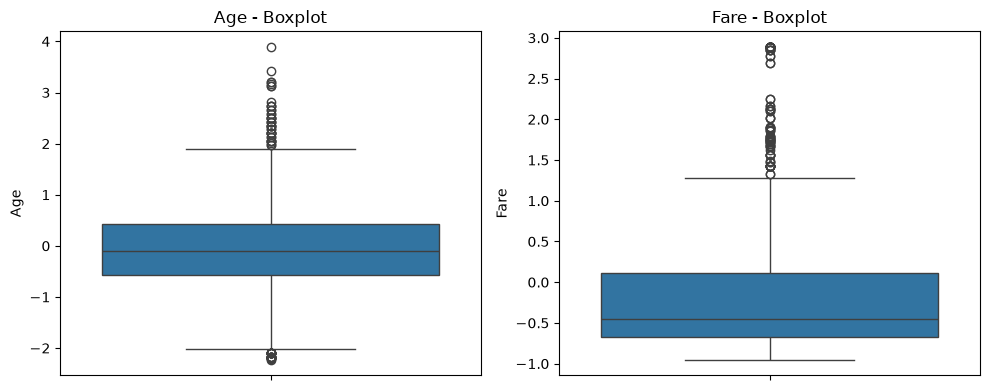

In [15]:
#C.outlier detection and treatment
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots to visually identify outliers - Titanic numerical columns
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=titanic_df['Age'], ax=axes[0])
axes[0].set_title('Age - Boxplot')
sns.boxplot(y=titanic_df['Fare'], ax=axes[1])
axes[1].set_title('Fare - Boxplot')
plt.tight_layout()
plt.show()


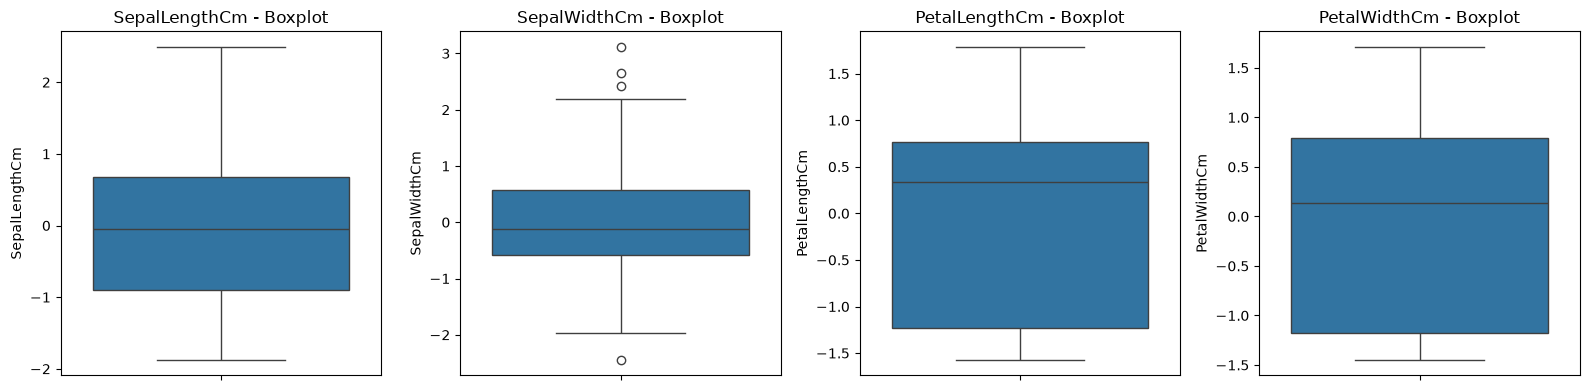

In [16]:
# Boxplots to visually identify outliers - Iris numerical columns
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
iris_num_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
for ax, col in zip(axes, iris_num_cols):
    sns.boxplot(y=iris_df[col], ax=ax)
    ax.set_title(f'{col} - Boxplot')
plt.tight_layout()
plt.show()

In [17]:
# Numeric confirmation of outliers using the IQR method (backs up what the boxplots show)
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((series < lower) | (series > upper)).sum()
    return n_outliers, lower, upper

print('=== Titanic ===')
for col in ['Age', 'Fare']:
    n_out, low, up = count_outliers_iqr(titanic_df[col])
    print(f"{col}: {n_out} outliers (IQR bounds: {low:.2f} to {up:.2f})")

print('\n=== Iris ===')
for col in ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']:
    n_out, low, up = count_outliers_iqr(iris_df[col])
    print(f"{col}: {n_out} outliers (IQR bounds: {low:.2f} to {up:.2f})")

=== Titanic ===
Age: 66 outliers (IQR bounds: -2.06 to 1.93)
Fare: 116 outliers (IQR bounds: -1.86 to 1.30)

=== Iris ===
SepalLengthCm: 0 outliers (IQR bounds: -3.26 to 3.04)
SepalWidthCm: 4 outliers (IQR bounds: -2.32 to 2.30)
PetalLengthCm: 0 outliers (IQR bounds: -4.21 to 3.75)
PetalWidthCm: 0 outliers (IQR bounds: -4.14 to 3.75)


Outlier decisions:

Fare (Titanic): Right-skewed with a long tail of very high fares (first-class luxury tickets). These are real values, not data errors, but they can dominate distance-based/scaled models, so I capped them at the 95th percentile rather than removing the records outright.

Age (Titanic): A few older passengers (up to 80) show as outliers on the boxplot, but age is a plausible, legitimate value - there's no reason to believe these are data entry errors. I chose to retain them rather than cap/remove, since removing real elderly passengers would bias survival analysis.

Iris features: A small number of points (e.g., in SepalWidthCm) fall outside the IQR whiskers. Since Iris is a small, well-curated dataset and these points likely reflect genuine natural variation between species rather than measurement error, I chose to retain all Iris records rather than remove or cap any.

In [20]:
#C.outlier detection and treatment
#detected the outliers for the fare column and capped the maximum at 111.481225
fare_95=titanic_df['Fare'].quantile(0.95)

titanic_df['Fare']=np.where(titanic_df['Fare']>fare_95,fare_95, titanic_df['Fare'])

print(titanic_df['Fare'].max())

2.8574307607150793


In [ ]:
# Age (Titanic) and all Iris columns are retained as-is (see reasoning above).
# No modification needed here - this cell documents the decision explicitly.
print('Age (Titanic) and Iris feature outliers retained - no rows removed or values capped.')

In [14]:
#D.categorial Variable Encoding
#encoded the sex and embarked columns in titanic dataset with one hot encoding
titanic_df=pd.get_dummies(titanic_df,columns=['Sex', 'Embarked'], drop_first=True)

#maping text to clean integer IDs for the target columns in Iris dataset
species_map={'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2}
iris_df['Species']=iris_df['Species'].map(species_map)


E. Feature Scaling

Why scaling matters: Many ML algorithms (e.g. KNN, logistic regression, SVM, gradient descent-based models) are sensitive to the scale of input features. Columns like Fare (range ~0-500) and Age (range ~0-80) would otherwise dominate distance calculations or gradient updates purely because of their larger numeric range, not because they're more important. StandardScaler transforms each feature to have mean 0 and standard deviation 1, putting all features on a comparable scale so the model treats them fairly.

In [13]:
#E.Feature Scaling
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler_titanic = StandardScaler()

# Select only the continuous numerical columns to scale
num_cols_titanic = ['Age', 'Fare']

# Fit and transform the columns, then overwrite them in the dataframe
titanic_df[num_cols_titanic] = scaler_titanic.fit_transform(titanic_df[num_cols_titanic])

# Let's inspect the first 5 rows to see the scaled values
print("=== Titanic Scaled Sample ===")
print(titanic_df[num_cols_titanic].head())

# Drop the redundant Id column first
if 'Id' in iris_df.columns:
    iris_df = iris_df.drop(columns=['Id'])

# Initialize a separate scaler for Iris
scaler_iris = StandardScaler()

# Select the measurement features (everything except the target 'Species')
num_cols_iris = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Fit and transform
iris_df[num_cols_iris] = scaler_iris.fit_transform(iris_df[num_cols_iris])

print("\n=== Iris Scaled Sample ===")
print(iris_df[num_cols_iris].head())

=== Titanic Scaled Sample ===
        Age      Fare
0 -0.565736 -0.700836
1  0.663861  1.491434
2 -0.258337 -0.677726
3  0.433312  0.868903
4  0.433312 -0.673447

=== Iris Scaled Sample ===
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      -0.900681      1.032057      -1.341272     -1.312977
1      -1.143017     -0.124958      -1.341272     -1.312977
2      -1.385353      0.337848      -1.398138     -1.312977
3      -1.506521      0.106445      -1.284407     -1.312977
4      -1.021849      1.263460      -1.341272     -1.312977


Export cleaned datasets
Saving the cleaned, encoded, and scaled datasets as required deliverables.


In [21]:
# Export cleaned datasets as required deliverables
titanic_df.to_csv('Titanic-Cleaned.csv', index=False)
iris_df.to_csv('Iris-Cleaned.csv', index=False)

print('Saved: Titanic-Cleaned.csv')
print('Saved: Iris-Cleaned.csv')

Saved: Titanic-Cleaned.csv
Saved: Iris-Cleaned.csv


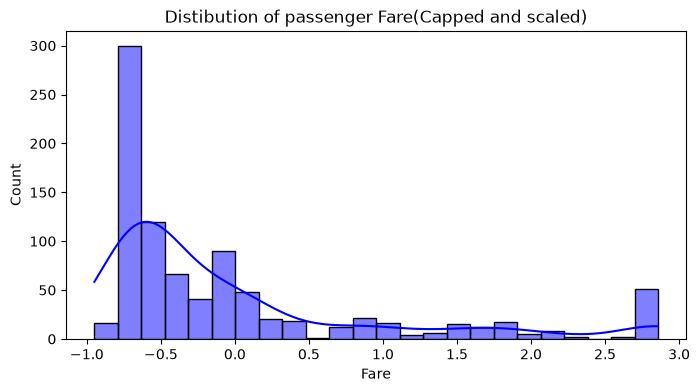

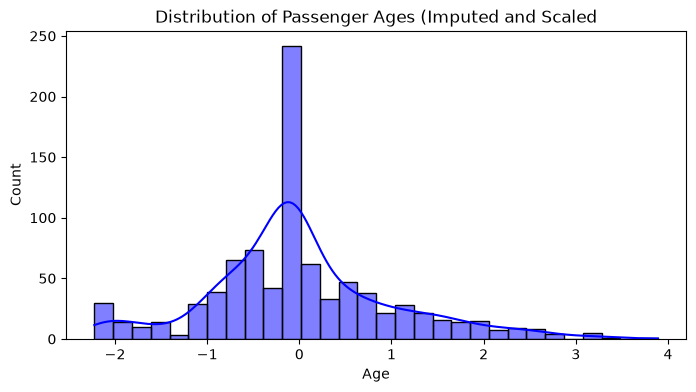

/tmp/ipykernel_191036/1142092605.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic_df, x='Survived', palette='Set1')


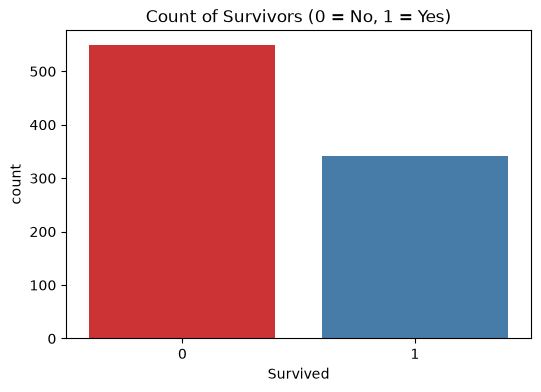

In [23]:
#Part 3 EDA
#Univariate Analysis
import matplotlib.pyplot as plt
import seaborn as sns

#1.plotting fare Distribution
plt.figure(figsize=(8,4))
sns.histplot(data=titanic_df,x='Fare', kde=True, color='blue')
plt.title('Distibution of passenger Fare(Capped and scaled)')
plt.show()

#2.Plotting Age distribution
plt.figure(figsize=(8,4))
sns.histplot(data=titanic_df, x='Age', kde=True, color='blue')
plt.title('Distribution of Passenger Ages (Imputed and Scaled')
plt.show()

#3.Checking the target distribution balance
plt.figure(figsize=(6,4))
sns.countplot(data=titanic_df, x='Survived', palette='Set1')
plt.title('Count of Survivors (0 = No, 1 = Yes)')
plt.show()
